In [60]:
""" Cell 1: Setup & Core Functions """
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances, rbf_kernel
from scipy.sparse.linalg import eigsh
from scipy.sparse.csgraph import shortest_path
from sklearn.neighbors import kneighbors_graph
from scipy.stats import gaussian_kde
from scipy.linalg import orthogonal_procrustes # Added for sensitivity analysis
import gudhi
import warnings
warnings.filterwarnings('ignore')

os.makedirs("../figures", exist_ok=True)

# ---------- Matplotlib Configuration ----------
sns.set_theme(style="ticks") 
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', size=12)
plt.rc('axes', labelsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)

print("Global plotting settings loaded.")

# ---------- Utilities ----------
def compute_diffusion_map(X, n_components=2, epsilon=None, t=1):
    D = euclidean_distances(X)
    if epsilon is None:
        epsilon = np.median(D[D > 0])
    
    W = rbf_kernel(X, gamma=1/(2*epsilon**2))
    np.fill_diagonal(W, 0)
    
    d_inv_sqrt = 1.0 / np.sqrt(W.sum(axis=1))
    A = d_inv_sqrt[:, None] * W * d_inv_sqrt[None, :] 
    
    eigvals, eigvecs = eigsh(A, k=n_components+1, which='LM')
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx][1:n_components+1]
    eigvecs = eigvecs[:, idx][:, 1:n_components+1] 
    
    for i in range(eigvecs.shape[1]):
        max_abs_idx = np.argmax(np.abs(eigvecs[:, i]))
        sign = np.sign(eigvecs[max_abs_idx, i])
        eigvecs[:, i] *= sign
        
    coords = eigvecs * (eigvals ** t)
    return coords, eigvecs, eigvals, epsilon

def nystrom_projection(X_new, X_train, eigvecs, eigvals, epsilon, t=1):
    K_new_train = rbf_kernel(X_new, X_train, gamma=1/(2*epsilon**2))
    d_train = np.sum(rbf_kernel(X_train, X_train, gamma=1/(2*epsilon**2)), axis=1)
    d_new = np.sum(K_new_train, axis=1)
    
    d_inv_sqrt_train = 1.0 / np.sqrt(d_train)
    d_inv_sqrt_new = 1.0 / np.sqrt(d_new)
    
    K_normalized = d_inv_sqrt_new[:, None] * K_new_train * d_inv_sqrt_train[None, :]
    psi_new = (K_normalized @ eigvecs) / eigvals
    return psi_new * (eigvals ** t)

def calculate_trajectory_metrics(group, geo_dist_matrix, global_indices):
    coords = group[["Diff1", "Diff2"]].values
    
    start_pos, end_pos = coords[0], coords[-1]
    net_displacement = np.linalg.norm(end_pos - start_pos)
    
    total_euc_path = 0
    total_geo_path = 0
    
    for i in range(len(coords) - 1):
        step_dist = np.linalg.norm(coords[i+1] - coords[i])
        total_euc_path += step_dist
        
        curr_idx = global_indices[group.index[i]]
        nxt_idx = global_indices[group.index[i+1]]
        geo_step = geo_dist_matrix[curr_idx, nxt_idx]
        
        if not np.isinf(geo_step):
            total_geo_path += geo_step
            
    tortuosity = total_euc_path / net_displacement if net_displacement > 0 else np.inf
    inefficiency = total_geo_path / total_euc_path if total_euc_path > 0 else np.nan
    
    return tortuosity, inefficiency

def compute_manifold_stability(var_subsets, data, n_components=2):
    """
    Computes alignment between manifolds from different variable sets using Procrustes.
    """
    scaler = StandardScaler()
    results = {}
    
    for name, vars_list in var_subsets.items():
        X_sub = scaler.fit_transform(data[vars_list])
        coords, _, _, _ = compute_diffusion_map(X_sub, n_components=n_components)
        results[name] = coords
        
    baseline = results['vdem_core']
    alignment_scores = {}
    
    for name, coords in results.items():
        if name != 'vdem_core':
            # Find optimal orthogonal rotation to align with baseline
            R, _ = orthogonal_procrustes(coords, baseline)
            aligned_coords = coords @ R
            # Calculate correlation of flattened coordinate arrays
            corr = np.corrcoef(baseline.flatten(), aligned_coords.flatten())[0, 1]
            alignment_scores[name] = corr
            
    return alignment_scores

def analyze_country_trajectory(country_name, df_ts_clean, df_typology, data_clean):
    """
    Generates a phase-space manifold plot and velocity diagnostic for a single country.
    """
    path = df_ts_clean[df_ts_clean["cname"] == country_name].sort_values("year")
    metrics = df_typology[df_typology["cname"] == country_name]

    if path.empty:
        print(f"Error: {country_name} not found.")
        return

    if not metrics.empty:
        print(f"--- {country_name} Trajectory Metrics ---")
        print(f"Typology: {metrics['Typology'].values[0]}")
        print(f"Tortuosity: {metrics['Tortuosity'].values[0]:.4f}")
        print(f"Inefficiency: {metrics['Inefficiency'].values[0]:.4f}")

    with plt.rc_context({'text.usetex': False, 'axes.unicode_minus': False}):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Manifold Plot
        ax1.scatter(data_clean["Diff1"], data_clean["Diff2"], c='lightgrey', s=20, alpha=0.3)
        ax1.plot(path["Diff1"], path["Diff2"], color='blue', marker='o', markevery=5, linewidth=2)
        ax1.scatter(path["Diff1"].iloc[0], path["Diff2"].iloc[0], color='green', s=100, label="1990")
        ax1.scatter(path["Diff1"].iloc[-1], path["Diff2"].iloc[-1], color='black', marker='*', s=200, label="2026")
        ax1.set_title(f"{country_name}: Manifold Path")
        ax1.legend()

        # Velocity Plot
        coords = path[["Diff1", "Diff2"]].values
        velocity = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
        ax2.plot(path["year"].values[1:], velocity, color='darkblue', lw=2)
        ax2.fill_between(path["year"].values[1:], velocity, color='blue', alpha=0.1)
        ax2.set_title("Annual Manifold Velocity")
        
        plt.tight_layout()
        plt.show()

Global plotting settings loaded.


In [61]:
""" Cell 2: Data Import & Cleaning """
df = pd.read_csv("../data/qog_std_cs_jan26.csv", low_memory=False)
df_ts = pd.read_csv("../data/qog_std_ts_jan26.csv", low_memory=False)

vdem_features = ['vdem_polyarchy', 'vdem_egal', 'vdem_corr']
wdi_features = ['wdi_popurb', 'wdi_lifexp', 'wdi_gdpcapcur']
undp_features = ['undp_hdi']

# FIX: Update the column selection to use your newly named lists
data = df[["cname"] + vdem_features + wdi_features + undp_features].copy().replace([-5, -4, -3, -2, -1, -9999], np.nan)
data["wdi_gdpcapcur"] = pd.to_numeric(data["wdi_gdpcapcur"], errors='coerce')

# K-NN imputation chosen over listwise deletion to prevent systematically dropping autocratic regimes
numeric_cols = data.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5, add_indicator=False)
data_clean = pd.DataFrame(imputer.fit_transform(data[numeric_cols]), columns=numeric_cols, index=data["cname"])
data_clean["cname"] = data["cname"].values

var_subsets = {
    'vdem_core': vdem_features, 
    'vdem, wdi': vdem_features + wdi_features, # The variables defining our primary manifold
    'vdem, wdi, undp': vdem_features + wdi_features + undp_features # Testing distortion with redundant structural features
}

alignment_scores = compute_manifold_stability(var_subsets, data_clean)
print("\n--- Manifold Stability (Procrustes Alignment vs. Core Institutional V-Dem Model) ---")
for name, score in alignment_scores.items():
    print(f"{name:15}: r = {score:.4f}")
print("------------------------------------------------------------------------------------\n")


--- Manifold Stability (Procrustes Alignment vs. Core Institutional V-Dem Model) ---
vdem, wdi      : r = 0.9020
vdem, wdi, undp: r = 0.8528
------------------------------------------------------------------------------------



Reference diffusion manifold created. Epsilon = 2.8754
X_scaled successfully defined with shape: (194, 6)
vdem_polyarchy : Diff1 = +0.811 | Diff2 = -0.349
vdem_egal      : Diff1 = +0.877 | Diff2 = -0.307
vdem_corr      : Diff1 = -0.890 | Diff2 = +0.179
wdi_popurb     : Diff1 = +0.611 | Diff2 = +0.645
wdi_lifexp     : Diff1 = +0.748 | Diff2 = +0.434
undp_hdi       : Diff1 = +0.766 | Diff2 = +0.385
log_gdp        : Diff1 = +0.737 | Diff2 = +0.442


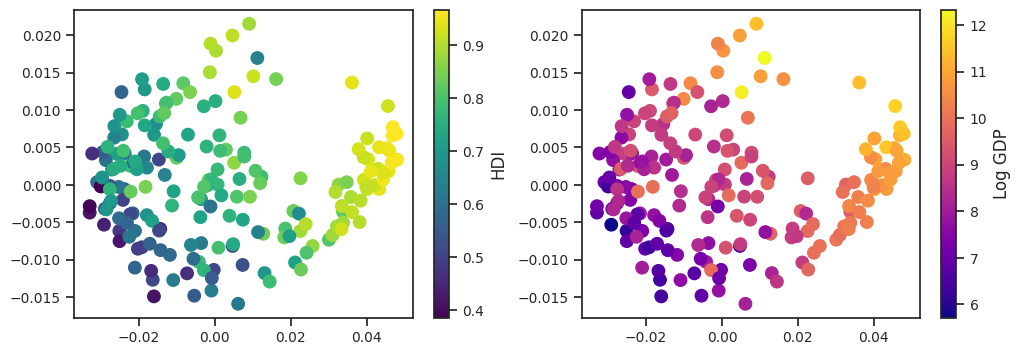

In [62]:
""" Cell 3: Reference Manifold & Axes Diagnostics """
# Verify feature lists
core_features = vdem_features + wdi_features
missing = [f for f in core_features if f not in data_clean.columns]
if missing:
    print(f"ERROR: Missing columns in data_clean: {missing}")
else:
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_clean[core_features])

    # Diffusion Map
    diff_coords, diff_eigvecs, diff_eigvals, diff_eps = compute_diffusion_map(X_scaled, n_components=2, t=1)
    data_clean["Diff1"] = diff_coords[:, 0]
    data_clean["Diff2"] = diff_coords[:, 1]

    # Log GDP (with safety offset for zeros)
    data_clean["log_gdp"] = np.log(data_clean["wdi_gdpcapcur"] + 1e-6)
    
    print(f"Reference diffusion manifold created. Epsilon = {diff_eps:.4f}")
    print(f"X_scaled successfully defined with shape: {X_scaled.shape}")

    # Diagnostic Correlations
    diagnostic_cols = [c for c in core_features if c != "wdi_gdpcapcur"] + ["undp_hdi", "log_gdp"]
    for col in diagnostic_cols:
        if col in data_clean.columns:
            corr1 = data_clean[col].corr(data_clean["Diff1"], method="spearman")
            corr2 = data_clean[col].corr(data_clean["Diff2"], method="spearman")
            print(f"{col:15}: Diff1 = {corr1:+.3f} | Diff2 = {corr2:+.3f}")
    
    # Plotting
    with plt.rc_context({'text.usetex': False, 'axes.unicode_minus': False}):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sc1 = axes[0].scatter(data_clean["Diff1"], data_clean["Diff2"], c=data_clean["undp_hdi"], cmap='viridis', s=80)
        plt.colorbar(sc1, ax=axes[0], label="HDI")
        sc2 = axes[1].scatter(data_clean["Diff1"], data_clean["Diff2"], c=data_clean["log_gdp"], cmap='plasma', s=80)
        plt.colorbar(sc2, ax=axes[1], label="Log GDP")
    
    # Save figures
    plt.savefig("../figures/fig1_reference_manifold.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig1_reference_manifold.eps", bbox_inches='tight')
    plt.show()

H1 -> High-dimensional loops (developmental voids) detected: 40

--- Primary Void Characteristics (Mean values bounding the hole) ---
vdem_polyarchy        0.331828
vdem_egal             0.472055
vdem_corr             0.492566
wdi_popurb           61.633201
wdi_lifexp           69.003977
wdi_gdpcapcur     34648.529396
dtype: float64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


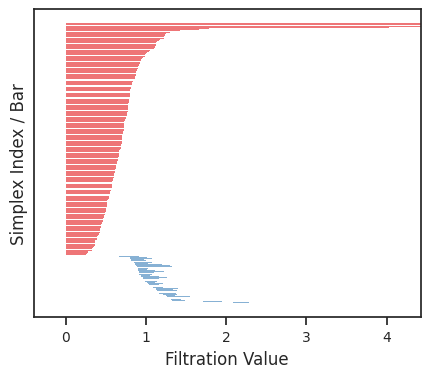

In [63]:
""" Cell 4: TDA & Identifying the Primary Void """
# Safety check: Ensure the manifold data exists
if 'X_scaled' not in locals():
    raise NameError("X_scaled is missing. Please run Cell 3 first to generate the manifold data.")

D_high = euclidean_distances(X_scaled)
search_radius = np.median(D_high[D_high > 0]) * 1.5  

rips_complex_hd = gudhi.RipsComplex(points=X_scaled, max_edge_length=search_radius)
simplex_tree_hd = rips_complex_hd.create_simplex_tree(max_dimension=2)
diag_hd = simplex_tree_hd.persistence(homology_coeff_field=2, min_persistence=0.1)

loops_h1 = [f for f in diag_hd if f[0] == 1]
print(f"H1 -> High-dimensional loops (developmental voids) detected: {len(loops_h1)}")

# Isolate the deepest topological void using KDE inverse 
kde = gaussian_kde(X_scaled.T)
density = kde(X_scaled.T)

# Find points bounding the lowest density region 
threshold = np.percentile(density, 15)
void_bounds = data_clean[density < threshold]

print("\n--- Primary Void Characteristics (Mean values bounding the hole) ---")
# UPDATED: Using the correct list name 'core_features'
print(void_bounds[core_features].mean())

# Persistence Barcode Logic
with plt.rc_context({
    'text.usetex': False, 
    'ps.usedistiller': None, 
    'pdf.fonttype': 42,
    'pgf.texsystem': 'pdflatex' 
}):
    fig, ax = plt.subplots(figsize=(5, 4))
    gudhi.plot_persistence_barcode(diag_hd, axes=ax)
    ax.set_title("")                         
    ax.set_xlabel("Filtration Value")        
    ax.set_ylabel("Simplex Index / Bar")     
    leg = ax.get_legend()
    if leg:
        leg.remove()                         
    
    # Save figures
    plt.savefig("../figures/fig2_persistence_barcode.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig2_persistence_barcode.eps", bbox_inches='tight')
    plt.show()

In [64]:
""" Cell 5: Historical Projection """
# Extract historical data using our validated 6-variable list
df_ts_clean = df_ts[["cname", "year"] + core_features].replace([-5, -4, -3, -2, -1, -9999], np.nan).dropna()
df_ts_clean = df_ts_clean[df_ts_clean["year"] >= 1990]

# Transform the historical data using the same scaler and variables as the reference manifold
X_ts_scaled = scaler.transform(df_ts_clean[core_features])

# Project the historical data onto the static geometry
X_diff_ts = nystrom_projection(X_ts_scaled, X_scaled, diff_eigvecs, diff_eigvals, diff_eps)

df_ts_clean["Diff1"] = X_diff_ts[:, 0]
df_ts_clean["Diff2"] = X_diff_ts[:, 1]
print(f"Projected {len(df_ts_clean)} historical observations (1990-2026).")

Projected 5628 historical observations (1990-2026).


In [65]:
""" Cell 6: Data-Driven Trajectory Typologies (K-Means) """
knn_graph = kneighbors_graph(X_diff_ts, n_neighbors=10, mode='distance', include_self=False)
geo_dist_matrix = shortest_path(csgraph=knn_graph, directed=False)
global_idx_map = {idx: i for i, idx in enumerate(df_ts_clean.index)}

results = []
for cname, group in df_ts_clean.groupby("cname"):
    if len(group) < 10: 
        continue
    tortuosity, inefficiency = calculate_trajectory_metrics(group, geo_dist_matrix, global_idx_map)
    
    # Filter out pure infinites to allow clustering
    if not np.isinf(tortuosity) and not np.isnan(inefficiency):
        results.append({
            "cname": cname,
            "Tortuosity": tortuosity,
            "Inefficiency": inefficiency
        })

df_typology = pd.DataFrame(results)

# Apply a log transformation to handle the extreme right-skew of the metrics
df_typology["log_Tortuosity"] = np.log(df_typology["Tortuosity"])
df_typology["log_Inefficiency"] = np.log(df_typology["Inefficiency"])

# Use K-Means on the log-transformed space
X_clust = df_typology[["log_Tortuosity", "log_Inefficiency"]].values
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_clust)
df_typology["Cluster"] = kmeans.labels_

# Map cluster centroids to conceptual labels
centroids = kmeans.cluster_centers_
sorted_idx = np.argsort(centroids[:, 0]) # Sort by log_Tortuosity
label_map = {sorted_idx[0]: "Direct", sorted_idx[1]: "Meandering", sorted_idx[2]: "Erratic"}
df_typology["Typology"] = df_typology["Cluster"].map(label_map)

print("\nTrajectory Typology Counts (Data-Driven, Log-Transformed):")
print(df_typology["Typology"].value_counts())


Trajectory Typology Counts (Data-Driven, Log-Transformed):
Typology
Direct        88
Meandering    67
Erratic       15
Name: count, dtype: int64


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


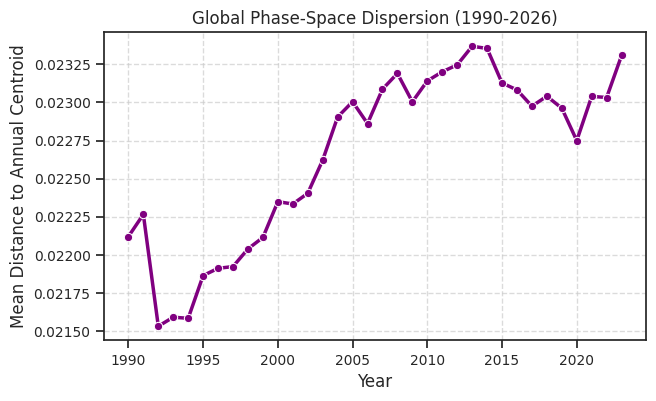

In [66]:
""" Cell 7: Systemic Dispersion (The "Macro" View) """
metrics = []
for year in sorted(df_ts_clean["year"].unique()):
    df_year = df_ts_clean[df_ts_clean["year"] == year]
    if len(df_year) < 30: 
        continue
        
    centroid = df_year[["Diff1", "Diff2"]].mean().values
    dispersion = np.mean([
        np.linalg.norm(row[["Diff1", "Diff2"]].values - centroid)
        for _, row in df_year.iterrows()
    ])
    
    metrics.append({"Year": year, "Dispersion": dispersion})

df_swarm = pd.DataFrame(metrics)

with plt.rc_context({'text.usetex': False, 'axes.unicode_minus': False}):
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=df_swarm, x="Year", y="Dispersion", marker='o', color='purple', linewidth=2.5)
    plt.title("Global Phase-Space Dispersion (1990-2026)")
    plt.xlabel("Year")
    plt.ylabel("Mean Distance to Annual Centroid")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Save figures
    plt.savefig("../figures/fig3_global_dispersion.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig3_global_dispersion.eps", bbox_inches='tight')
    plt.show()

--- Country Membership by Trajectory Typology ---

DIRECT (88 countries):
Angola, Australia, Austria, Azerbaijan, Bahrain, Barbados, Belarus
Belgium, Benin, Bhutan, Bosnia and Herzegovina, Cabo Verde, Cambodia, Cameroon
Chad, Chile, China, Colombia, Costa Rica, Croatia, Cyprus
Czechia, Denmark, Djibouti, Dominican Republic (the), Equatorial Guinea, Eritrea, Estonia
Finland, France, Gabon, Gambia (the), Georgia, Ghana, Guatemala
Hungary, India, Ireland, Israel, Italy, Jamaica, Kenya
Korea (the Republic of), Lao People's Democratic Republic (the), Latvia, Lithuania, Luxembourg, Malaysia, Maldives
Malta, Montenegro, Morocco, Nepal, Netherlands (the), New Zealand, Nicaragua
Nigeria, Oman, Panama, Paraguay, Portugal, Russian Federation (the), Sao Tome and Principe
Saudi Arabia, Senegal, Seychelles, Sierra Leone, Singapore, Slovakia, South Africa
Switzerland, Syrian Arab Republic (the), Tajikistan, Tanzania, the United Republic of, Timor-Leste, Tunisia, Turkey
Turkmenistan, Uganda, United Ar

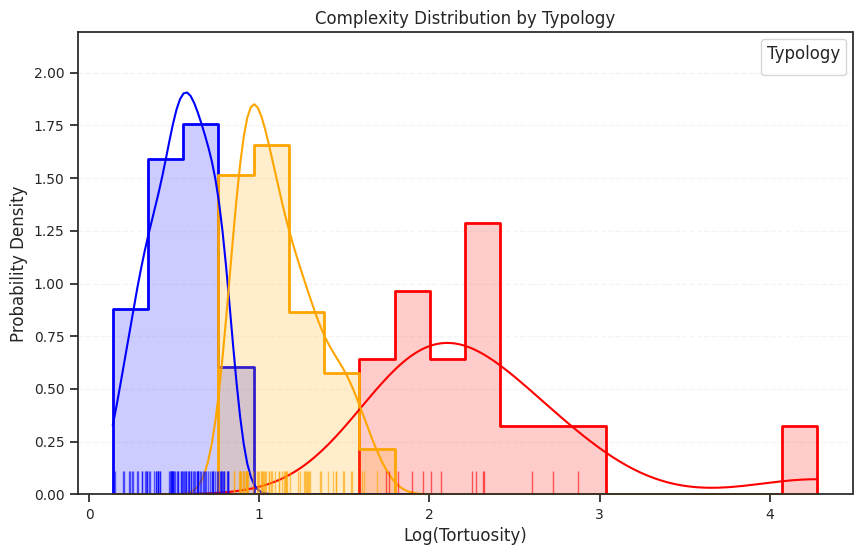

In [67]:
""" Cell 8: Membership & Standardized Distribution (The "Group" View) """
# Previously Cell 9
print("--- Country Membership by Trajectory Typology ---")
typo_palette = {"Direct": "blue", "Meandering": "orange", "Erratic": "red"}

for typo in ["Direct", "Meandering", "Erratic"]:
    members = sorted(df_typology[df_typology["Typology"] == typo]["cname"].unique())
    print(f"\n{typo.upper()} ({len(members)} countries):")
    for i in range(0, len(members), 7):
        print(", ".join(members[i:i+7]))

with plt.rc_context({'text.usetex': False, 'axes.unicode_minus': False}):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_typology, x="log_Tortuosity", hue="Typology", 
                 palette=typo_palette, kde=True, element="step", 
                 stat="density", common_norm=False, alpha=0.2, linewidth=2)
    sns.rugplot(data=df_typology, x="log_Tortuosity", hue="Typology", 
                palette=typo_palette, height=0.05, alpha=0.6)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    target_order = ["Direct", "Meandering", "Erratic"]
    ordered_labels = [l for l in target_order if l in by_label]
    ordered_handles = [by_label[l] for l in ordered_labels]
    plt.legend(ordered_handles, ordered_labels, title="Typology", frameon=True)
    
    plt.title("Complexity Distribution by Typology")
    plt.xlabel("Log(Tortuosity)")
    plt.ylabel("Probability Density")
    plt.grid(axis='y', linestyle='--', alpha=0.2)
    plt.show()

In [ ]:
""" Cell 9: Individual Country Case Study """
# Run for any country in the dataset
analyze_country_trajectory("Japan", df_ts_clean, df_typology, data_clean)

Error: jAPAN not found.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


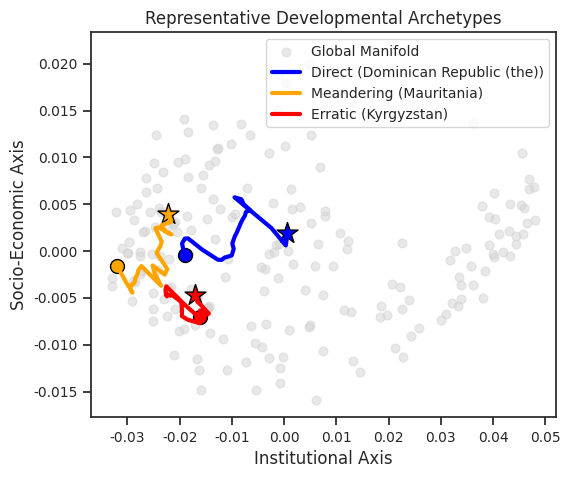

In [59]:
""" Cell 10: Final Archetype Summary Figure """
# Identify the most representative country for each group
examples = {}
for typo in ["Direct", "Meandering", "Erratic"]:
    subset = df_typology[df_typology["Typology"] == typo].copy()
    med_tort = subset["Tortuosity"].median()
    med_ineff = subset["Inefficiency"].median()
    subset["dist_to_median"] = np.sqrt((subset["Tortuosity"] - med_tort)**2 + (subset["Inefficiency"] - med_ineff)**2)
    exemplar = subset.loc[subset["dist_to_median"].idxmin(), "cname"]
    examples[typo] = exemplar

# Plotting the overlaid trajectories
colors = {"Direct": "blue", "Meandering": "orange", "Erratic": "red"}

with plt.rc_context({'text.usetex': False, 'axes.unicode_minus': False}):
    plt.figure(figsize=(6, 5))
    plt.scatter(data_clean["Diff1"], data_clean["Diff2"], c='lightgrey', s=40, alpha=0.5, label="Global Manifold")

    for typo, cname in examples.items():
        country_data = df_ts_clean[df_ts_clean["cname"] == cname].sort_values("year")
        x, y = country_data["Diff1"].values, country_data["Diff2"].values
        plt.plot(x, y, color=colors[typo], label=f"{typo} ({cname})", linewidth=3)
        plt.scatter(x[0], y[0], color=colors[typo], marker='o', s=100, edgecolor='black')
        plt.scatter(x[-1], y[-1], color=colors[typo], marker='*', s=250, edgecolor='black')

    plt.title("Representative Developmental Archetypes")
    plt.xlabel("Institutional Axis")
    plt.ylabel("Socio-Economic Axis")
    plt.legend()
    
    # Save figures
    plt.savefig("../figures/fig4_trajectory_typologies.png", dpi=300, bbox_inches='tight')
    plt.savefig("../figures/fig4_trajectory_typologies.eps", bbox_inches='tight')
    plt.show()